**Functional Data Analysis of ECG Heartbeat Signals**

This project applies Functional Data Analysis ideas to ECG heartbeat signals from the ECG200 dataset.

The main goal is to study whether ECG signal shapes differ between the two classesThis project applies Functional Data Analysis ideas to ECG heartbeat signals from the ECG200 dataset.

The main goal is to study whether ECG signal shapes differ between the two classes of heartbeats.

## Introduction

Electrocardiogram signals are naturally observed over time. For this reason, they are suitable for Functional Data Analysis, where each observation is treated as a function rather than as a finite vector of independent measurements.

In this project, each ECG heartbeat signal is represented as a curve over a common normalized time interval. The purpose is not to build a clinical diagnostic model, but to demonstrate how Functional Data Analysis tools can be used to explore, smooth, compare, and reduce the dimensionality of ECG signal data.

The main research question is:

**Can Functional Data Analysis help identify differences in the shape of ECG heartbeat signals between the two classes?**

## 1. Import Libraries

In this section, we import the Python libraries needed for data loading, visualization, smoothing, Functional PCA approximation, and classification.

In [9]:
# Import the necessary libraries
# These libraries are already available in Google Colab

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

## 2. Load the ECG200 Dataset

The ECG200 dataset contains ECG heartbeat signals.  
The first column is the class label, and the remaining columns are ECG signal values observed over time.

In [10]:
# Load the ECG200 dataset directly from online TSV files
# The first column contains the class label
# The remaining columns contain the ECG signal values

train_url = "https://raw.githubusercontent.com/Shuchismita-Biswas/AML_Project_Fall19/master/ECG200_TRAIN.tsv"
test_url = "https://raw.githubusercontent.com/Shuchismita-Biswas/AML_Project_Fall19/master/ECG200_TEST.tsv"

train_df = pd.read_csv(train_url, sep=r"\s+", header=None)
test_df = pd.read_csv(test_url, sep=r"\s+", header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (100, 97)
Test shape: (100, 97)


,0,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,96
0,-1,0.502055,0.542163,0.722383,1.428885,2.136516,2.281149,1.936274,1.468890,1.008845,...,0.931043,0.610298,0.638894,0.684679,0.583238,0.640522,0.708585,0.705011,0.713815,0.433765
1,1,0.147647,0.804668,0.367771,0.243894,0.026614,-0.274402,0.096731,-0.747731,-1.609777,...,-0.533503,-0.400228,0.176084,1.111768,2.438428,2.734889,1.736054,0.036857,-1.265074,-0.208024
2,-1,0.316646,0.243199,0.370471,1.063738,1.678187,1.759558,1.697717,1.612159,1.168188,...,0.764229,0.610621,0.552900,0.566786,0.604002,0.777068,0.812345,0.748848,0.818042,0.539347
3,-1,1.168874,2.075901,1.760141,1.606446,1.949046,1.302842,0.459332,0.516412,0.852180,...,0.419006,0.723888,1.323947,2.136488,1.746597,1.470220,1.893512,1.256949,0.800407,0.731540
4,1,0.648658,0.752026,2.636231,3.455716,2.118157,0.520620,-0.188627,0.780818,0.933775,...,-0.097869,-0.136787,-0.340237,-0.089441,-0.080297,-0.192584,-0.304704,-0.454556,0.314590,0.582190


## Dataset Description

The dataset used in this project is ECG200. Each time series traces the electrical activity recorded during one heartbeat. The two classes correspond to normal heartbeat and myocardial infarction heartbeat signals.

The dataset contains 200 ECG signals. Each signal is sampled at 96 time points. In this project, each row of the dataset is treated as one functional observation.

The first column of the dataset contains the class label, while the remaining 96 columns contain the ECG signal values observed over time.

## Research Questions

The project focuses on the following research questions:

1. Can ECG heartbeat signals be represented as functional data?
2. Do the two classes have different average ECG curve shapes?
3. What are the main modes of variation among the ECG curves?
4. Can the first few FPCA scores summarize enough information to help distinguish between the two classes?

## 3. Create Features and Labels

The feature matrix `X` contains the ECG signal values.  
The vector `y` contains the class labels.

Each row of `X` is treated as one ECG curve.

In [11]:
# Separate labels and signal values
# X contains the ECG curves
# y contains the class labels

X_train = train_df.iloc[:, 1:].to_numpy(dtype=float)
y_train = train_df.iloc[:, 0].to_numpy()

X_test = test_df.iloc[:, 1:].to_numpy(dtype=float)
y_test = test_df.iloc[:, 0].to_numpy()

# Combine train and test data into one dataset for exploratory analysis

X = np.vstack([X_train, X_test])
y = np.concatenate([y_train, y_test])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Full X shape:", X.shape)
print("Full y shape:", y.shape)
print("Class counts:")
print(pd.Series(y).value_counts())

X_train shape: (100, 96)
X_test shape: (100, 96)
Full X shape: (200, 96)
Full y shape: (200,)
Class counts:
 1    133
-1     67
Name: count, dtype: int64


## 4. Create a Normalized Time Grid

Each ECG signal has 96 time points.  
Since all signals have the same length, they can be represented on a common normalized time interval from 0 to 1.

In [12]:
# Create a normalized time grid from 0 to 1
# This allows each ECG signal to be treated as a function over a common interval

n_samples, n_time_points = X.shape
time_grid = np.linspace(0, 1, n_time_points)

print("Number of ECG signals:", n_samples)
print("Number of time points per signal:", n_time_points)
print("First 5 time points:", time_grid[:5])

Number of ECG signals: 200
Number of time points per signal: 96
First 5 time points: [0.         0.01052632 0.02105263 0.03157895 0.04210526]


## 5. Plot Raw ECG Signals

In this section, we visualize some raw ECG heartbeat signals to inspect their curve structure.

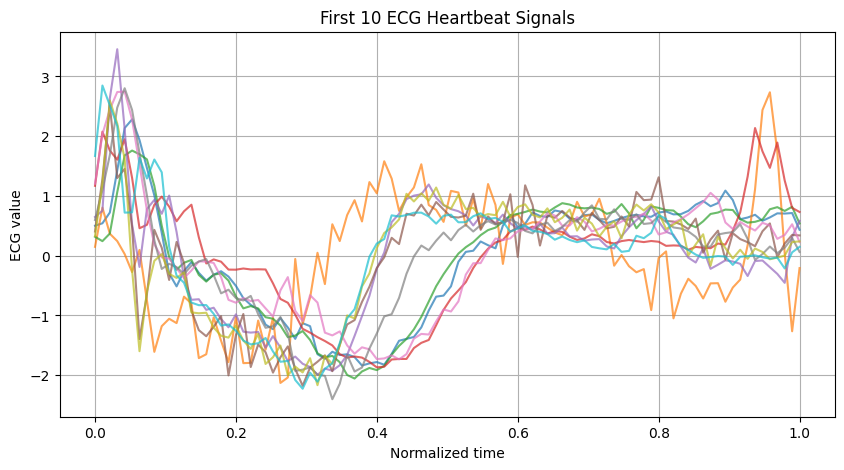

In [13]:
# Plot the first 10 ECG signals
# Each line represents one heartbeat signal observed over normalized time

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.plot(time_grid, X[i], alpha=0.7)

plt.title("First 10 ECG Heartbeat Signals")
plt.xlabel("Normalized time")
plt.ylabel("ECG value")
plt.grid(True)
plt.show()

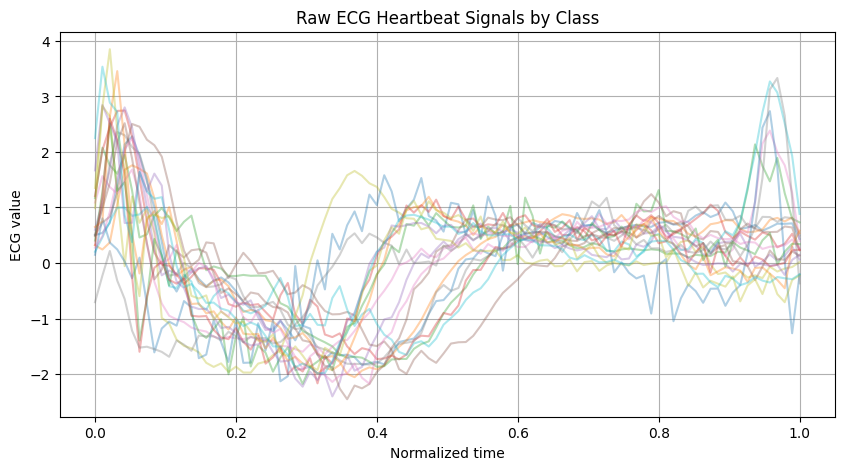

Class labels: [-1  1]


In [14]:
# Identify the unique class labels in the dataset
# Then plot a small number of raw ECG signals from each class

unique_labels = np.unique(y)

plt.figure(figsize=(10, 5))

for label in unique_labels:
    idx = np.where(y == label)[0][:10]
    for i in idx:
        plt.plot(time_grid, X[i], alpha=0.35)

plt.title("Raw ECG Heartbeat Signals by Class")
plt.xlabel("Normalized time")
plt.ylabel("ECG value")
plt.grid(True)
plt.show()

print("Class labels:", unique_labels)

## Methodology

The analysis follows four main steps.

First, each ECG signal is represented as a function observed on a common normalized time interval from 0 to 1.

Second, smoothing is applied to reduce small local fluctuations in the signals. This gives cleaner functional observations while preserving the main heartbeat shape.

Third, the mean function of each class is computed and compared. This helps identify whether the two classes differ in their average ECG shape.

Fourth, PCA is applied to the smoothed curves observed on the common grid. Since the data are treated as functions sampled at the same time points, this is interpreted as a practical approximation of Functional Principal Component Analysis for discretely observed functional data.

Finally, as an additional step, the first three FPCA scores are used as low-dimensional features in a simple logistic regression classifier.

## 6. Smoothing

Smoothing is applied to reduce small local fluctuations in the ECG signals while keeping the main heartbeat shape.

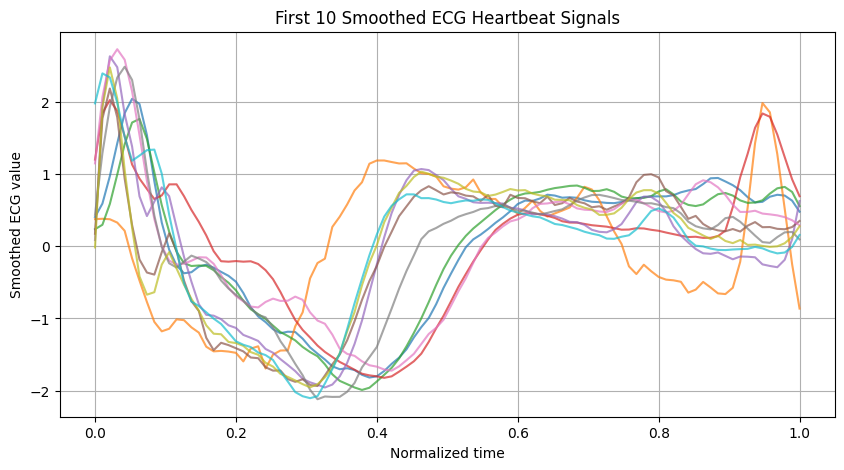

In [15]:
# Apply Savitzky-Golay smoothing to the ECG signals
# Smoothing reduces small local fluctuations and gives cleaner curves

X_smooth = savgol_filter(
    X,
    window_length=9,
    polyorder=3,
    axis=1
)

# Plot the first 10 smoothed ECG signals

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.plot(time_grid, X_smooth[i], alpha=0.7)

plt.title("First 10 Smoothed ECG Heartbeat Signals")
plt.xlabel("Normalized time")
plt.ylabel("Smoothed ECG value")
plt.grid(True)
plt.show()

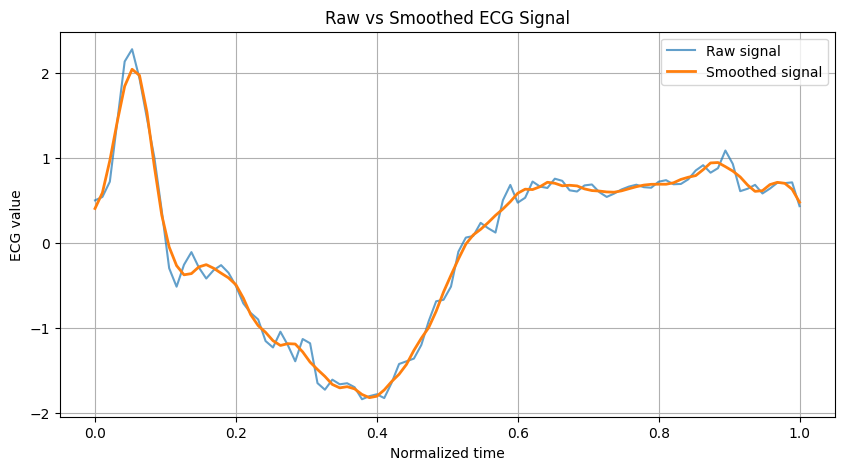

In [16]:
# Compare one raw ECG signal with its smoothed version
# This plot shows the effect of the smoothing step on one heartbeat curve

signal_index = 0

plt.figure(figsize=(10, 5))

plt.plot(time_grid, X[signal_index], label="Raw signal", alpha=0.7)
plt.plot(time_grid, X_smooth[signal_index], label="Smoothed signal", linewidth=2)

plt.title("Raw vs Smoothed ECG Signal")
plt.xlabel("Normalized time")
plt.ylabel("ECG value")
plt.legend()
plt.grid(True)
plt.show()

## 7. Mean Function Comparison

The mean function represents the average ECG curve in each class.  
Comparing class mean functions helps us study whether the average heartbeat shapes differ between the two groups.

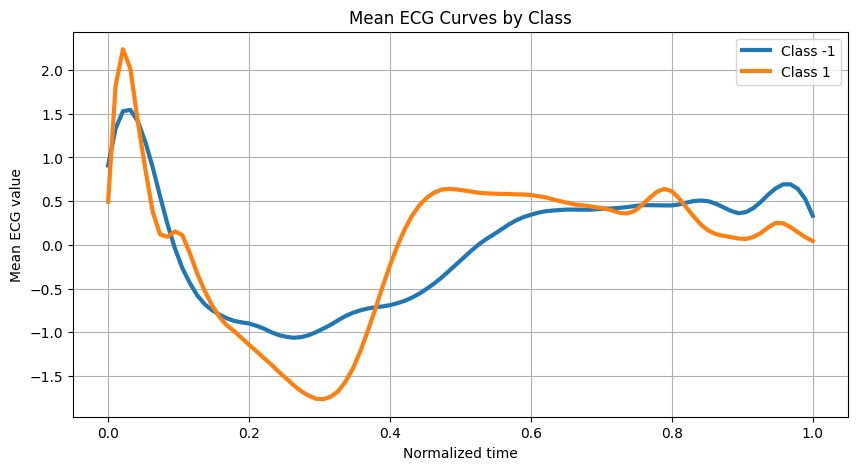

In [17]:
# Compute and plot the mean ECG curve for each class
# The mean function represents the average heartbeat shape in each group

plt.figure(figsize=(10, 5))

for label in unique_labels:
    mean_curve = X_smooth[y == label].mean(axis=0)
    plt.plot(time_grid, mean_curve, linewidth=3, label=f"Class {label}")

plt.title("Mean ECG Curves by Class")
plt.xlabel("Normalized time")
plt.ylabel("Mean ECG value")
plt.legend()
plt.grid(True)
plt.show()

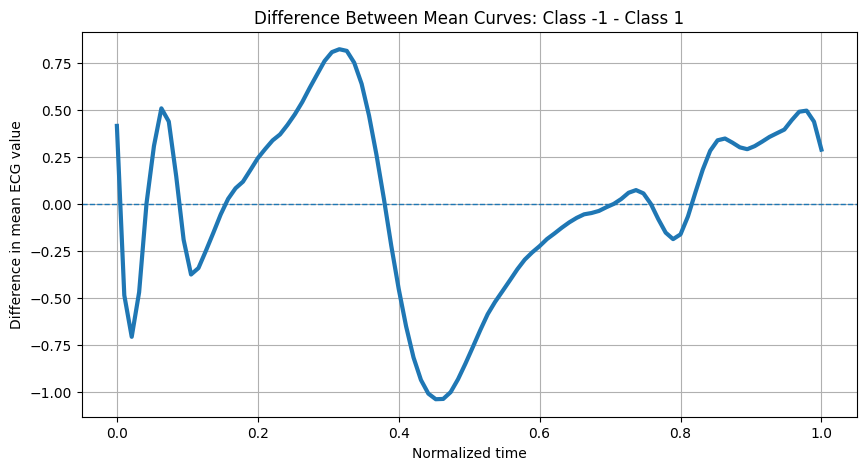

In [18]:
# Compute the mean curve for each class
# Then calculate and plot the difference between the two mean functions

label_1 = unique_labels[0]
label_2 = unique_labels[1]

mean_curve_1 = X_smooth[y == label_1].mean(axis=0)
mean_curve_2 = X_smooth[y == label_2].mean(axis=0)

mean_difference = mean_curve_1 - mean_curve_2

plt.figure(figsize=(10, 5))

plt.plot(time_grid, mean_difference, linewidth=3)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Difference Between Mean Curves: Class {label_1} - Class {label_2}")
plt.xlabel("Normalized time")
plt.ylabel("Difference in mean ECG value")
plt.grid(True)
plt.show()

## 8. Functional PCA Approximation

Functional Principal Component Analysis is used to study the main modes of variation among the ECG curves.

Since the curves are observed on a common discrete grid, PCA applied to the smoothed curves can be interpreted as an approximation of Functional PCA.

In [19]:
# Apply PCA to the smoothed ECG curves
# Because each ECG signal is treated as a function on a common grid,
# this can be interpreted as an approximation of Functional PCA

pca = PCA(n_components=3)

scores = pca.fit_transform(X_smooth)

print("FPCA scores shape:", scores.shape)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("Total explained variance by the first 3 components:")
print(pca.explained_variance_ratio_.sum())

FPCA scores shape: (200, 3)
Explained variance ratio:
[0.413469   0.26972877 0.10681244]
Total explained variance by the first 3 components:
0.7900102102966794


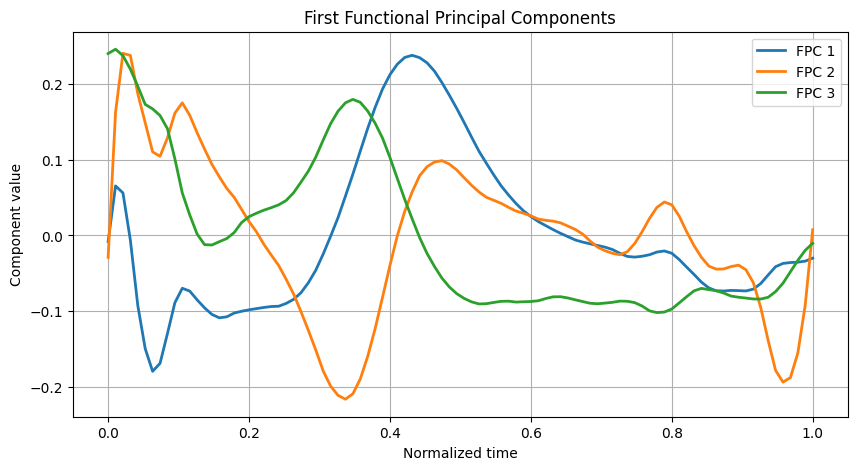

In [20]:
# Plot the first three principal component functions
# These components show the main directions of variation among the ECG curves

components = pca.components_

plt.figure(figsize=(10, 5))

for i in range(3):
    plt.plot(time_grid, components[i], linewidth=2, label=f"FPC {i+1}")

plt.title("First Functional Principal Components")
plt.xlabel("Normalized time")
plt.ylabel("Component value")
plt.legend()
plt.grid(True)
plt.show()

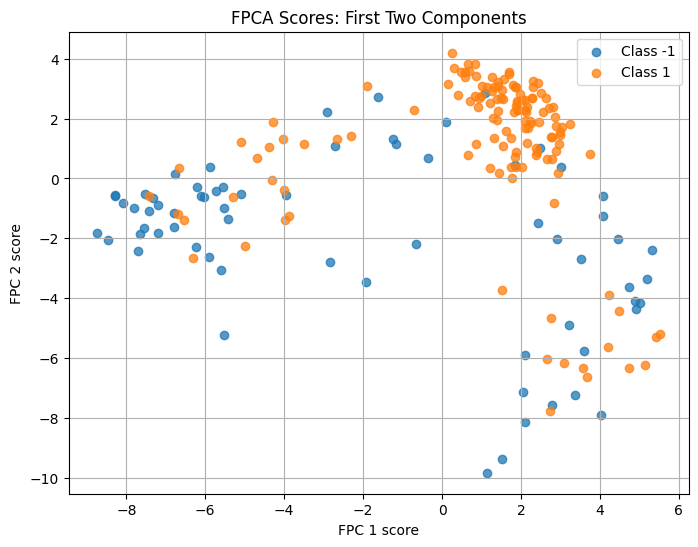

In [21]:
# Plot the scores of the first two functional principal components
# Each point represents one ECG signal
# This helps us see whether the two classes are separated in the FPCA space

plt.figure(figsize=(8, 6))

for label in unique_labels:
    idx = y == label
    plt.scatter(
        scores[idx, 0],
        scores[idx, 1],
        alpha=0.75,
        label=f"Class {label}"
    )

plt.title("FPCA Scores: First Two Components")
plt.xlabel("FPC 1 score")
plt.ylabel("FPC 2 score")
plt.legend()
plt.grid(True)
plt.show()

## 9. Classification Using FPCA Scores

As an additional step, the first three FPCA scores are used as low-dimensional features for a simple logistic regression classifier.

In [22]:
# Encode class labels into numerical values
# Logistic regression requires numerical class labels

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Use logistic regression as a simple classifier
# The input features are the first three FPCA scores

clf = LogisticRegression(max_iter=1000)

# Use stratified 5-fold cross-validation
# Stratification keeps class proportions similar in each fold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

accuracy_scores = cross_val_score(
    clf,
    scores[:, :3],
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation accuracy scores:")
print(accuracy_scores)

print("Mean accuracy:")
print(accuracy_scores.mean())

print("Standard deviation:")
print(accuracy_scores.std())

Cross-validation accuracy scores:
[0.875 0.8   0.625 0.85  0.85 ]
Mean accuracy:
0.8
Standard deviation:
0.09082951062292476


## 10. Summary of Results

This table summarizes the main numerical results of the analysis.

In [23]:
# Create a summary table with the main numerical results
# This table can be included in the final project report

summary_table = pd.DataFrame({
    "Quantity": [
        "Number of ECG signals",
        "Number of time points per signal",
        "Number of classes",
        "Variance explained by FPC 1",
        "Variance explained by FPC 2",
        "Variance explained by FPC 3",
        "Total variance explained by first 3 FPCs",
        "Mean classification accuracy"
    ],
    "Value": [
        n_samples,
        n_time_points,
        len(unique_labels),
        round(pca.explained_variance_ratio_[0], 4),
        round(pca.explained_variance_ratio_[1], 4),
        round(pca.explained_variance_ratio_[2], 4),
        round(pca.explained_variance_ratio_.sum(), 4),
        round(accuracy_scores.mean(), 4)
    ]
})

summary_table

,Quantity,Value
0,Number of ECG signals,200.0000
1,Number of time points per signal,96.0000
2,Number of classes,2.0000
3,Variance explained by FPC 1,0.4135
4,Variance explained by FPC 2,0.2697
5,Variance explained by FPC 3,0.1068
6,Total variance explained by first 3 FPCs,0.7900
7,Mean classification accuracy,0.8000


## Results

The analysis was performed on 200 ECG heartbeat signals, each observed at 96 time points. The signals were first represented on a common normalized time interval and then smoothed.

The mean function comparison showed that the two classes have different average ECG shapes. This indicates that the difference between the groups is not only at individual time points, but also in the overall shape of the heartbeat curves.

The Functional PCA approximation produced three main components. The first component explains 41.35% of the total variation, the second component explains 26.97%, and the third component explains 10.68%. Together, the first three components explain approximately 79% of the total variation.

This means that the original ECG curves, each with 96 time points, can be summarized using only three FPCA scores while preserving a large part of the variation in the data.

As an additional analysis, logistic regression was applied using only the first three FPCA scores. The mean cross-validation accuracy was 80%, suggesting that the FPCA scores contain useful information for distinguishing between the two ECG classes.

## Discussion

The results suggest that Functional Data Analysis is appropriate for this dataset because ECG signals are naturally curve-like observations. Treating each signal as a function allows us to focus on the overall shape of the heartbeat rather than analysing each time point separately.

The mean curve comparison is useful because it provides a direct visual way to compare the average heartbeat shapes of the two classes. The difference between the mean functions highlights the regions of normalized time where the two groups differ more strongly.

The FPCA approximation is useful because it reduces the dimensionality of the data. Instead of using all 96 time points, the first three FPCA scores summarize about 79% of the total variation. This makes the data easier to visualize and also useful for simple classification.

The classification result should be interpreted carefully. The goal of this project is not to build a medical diagnostic model, but to show that the FPCA representation captures meaningful shape information from the ECG curves.

## Conclusion

This project analysed ECG heartbeat signals using Functional Data Analysis ideas.

Each ECG signal was treated as a function observed over a common normalized time interval. Smoothing was applied to obtain cleaner curves, and class mean functions were compared to study differences in average ECG shape.

The Functional PCA approximation showed that the first three components explain about 79% of the total variation in the ECG curves. This demonstrates that the main structure of the original 96-dimensional signals can be represented in a much lower-dimensional space.

The additional classification step achieved about 80% mean cross-validation accuracy using only the first three FPCA scores. This suggests that the FPCA scores capture useful shape information.

Overall, the project shows that Functional Data Analysis provides a useful framework for representing, visualizing, comparing, and summarizing ECG heartbeat signals.

## Limitations

This project has some limitations.

First, the dataset is relatively small, with only 200 ECG signals. Therefore, the classification accuracy should be interpreted carefully.

Second, the time interval was normalized to [0, 1]. This means that the analysis focuses mainly on the shape of the curves rather than exact physical timing.

Third, PCA was applied to smoothed curves observed on a common discrete grid. For this reason, it is described as an approximation of Functional PCA for discretely observed functional data.

Finally, this project is exploratory and educational. It should not be interpreted as a clinical diagnostic model.

## References

1. Time Series Classification. ECG200 dataset description.  
   https://timeseriesclassification.com/description.php?Dataset=ECG200

2. RDocumentation. ECG200 Electrocardiogram Data.  
   https://www.rdocumentation.org/packages/DATAstudio/versions/1.2.3/topics/ecg200

3. SciPy Documentation. `scipy.signal.savgol_filter`.  
   https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html

4. Scikit-learn Documentation. `sklearn.decomposition.PCA`.  
   https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

5. Scikit-learn Documentation. `StratifiedKFold`.  
   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html

6. Scikit-learn Documentation. `LogisticRegression`.  
   https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html